In [7]:
import numpy as np
import pandas as p
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
upload = files.upload()


Saving data.csv to data.csv


In [34]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [35]:
df.shape

(569, 33)

In [36]:
print("Shape:", df.shape)
df.info()

Shape: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

In [37]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [38]:
df.isnull().sum().sort_values(ascending=False).head()

,0
Unnamed: 32,569
id,0
diagnosis,0
texture_mean,0
radius_mean,0


In [39]:
df = df.drop(columns=["id", "Unnamed: 32"])
print("New shape:", df.shape)
df.head()

New shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [40]:
df["diagnosis"] = df["diagnosis"].map({
    "B" : 0,
    "M": 1
})

df["diagnosis"].value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64>

In [41]:
x = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (569, 30)
y shape: (569,)


In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size= 0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 455
Testing samples: 114


In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)

y_prediction_logistic = logistic_model.predict(x_test)
print("Model trained successfully")

Model trained successfully


Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219
ROC AUC Score: 0.996031746031746

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



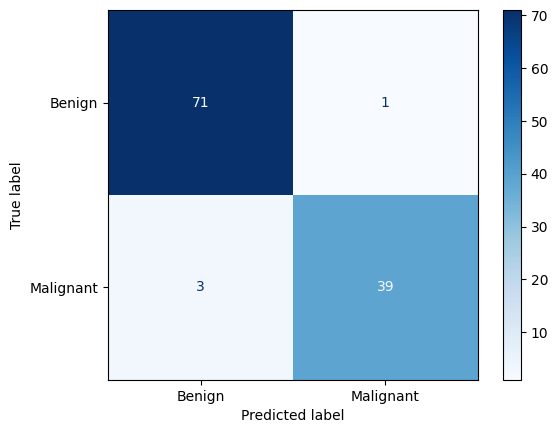

In [53]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predicted probability of malignancy
y_prob_logistic = logistic_model.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_prediction_logistic))
print("Precision:", precision_score(y_test, y_prediction_logistic))
print("Recall:", recall_score(y_test, y_prediction_logistic))
print("F1 Score:", f1_score(y_test, y_prediction_logistic))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_logistic))

print("\nClassification Report:")
print(
    classification_report (
        y_test,
        y_prediction_logistic,
        target_names=["Benign", "Malignant"]
    )
)

# Confusion matrix

cm = confusion_matrix(y_test, y_prediction_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [60]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

# Random Forest does not require scaling

random_forest_model.fit(x_train, y_train)

y_prediction_rf  = random_forest_model.predict(x_test)
y_prob_Rf = random_forest_model.predict_proba(x_test)[:,1]
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


Random Forest Result
-----------------------------
Accuracy :  0.9649122807017544
Precision :  1.0
Recall :  0.9047619047619048
F1 Score :  0.95
ROC AUC Score :  0.9970238095238095

Classification Report
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



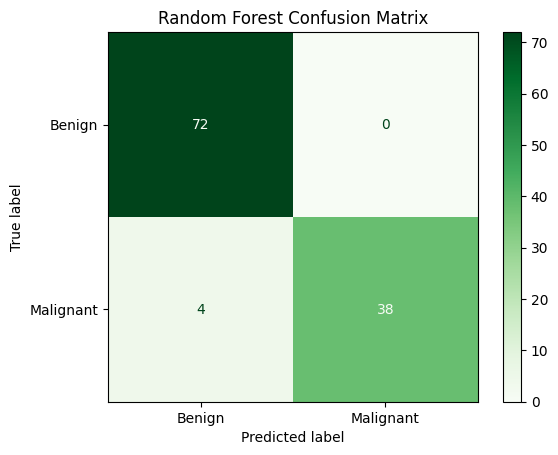

In [62]:
print("Random Forest Result")
print("-----------------------------")


print("Accuracy : ", accuracy_score(y_test, y_prediction_rf))
print("Precision : ", precision_score(y_test, y_prediction_rf))
print("Recall : ", recall_score(y_test, y_prediction_rf))
print("F1 Score : ", f1_score(y_test, y_prediction_rf))
print("ROC AUC Score : ", roc_auc_score(y_test, y_prob_Rf))


print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_prediction_rf,
        target_names=["Benign", "Malignant"]
    )
)
# Random Forest confusion matrix

cm_rf = confusion_matrix(y_test, y_prediction_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benign", "Malignant"]
)

disp_rf.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [67]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_prediction_logistic),
        accuracy_score(y_test, y_prediction_rf)
    ],

    "Precision": [
        precision_score(y_test, y_prediction_logistic),
        precision_score(y_test, y_prediction_rf)
    ],

    "Recall": [
        recall_score(y_test, y_prediction_logistic),
        recall_score(y_test, y_prediction_rf)
    ],

    "F1-score": [
        f1_score(y_test, y_prediction_logistic),
        f1_score(y_test, y_prediction_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_Rf)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9649,0.975,0.9286,0.9512,0.996
1,Random Forest,0.9649,1.000,0.9048,0.9500,0.997


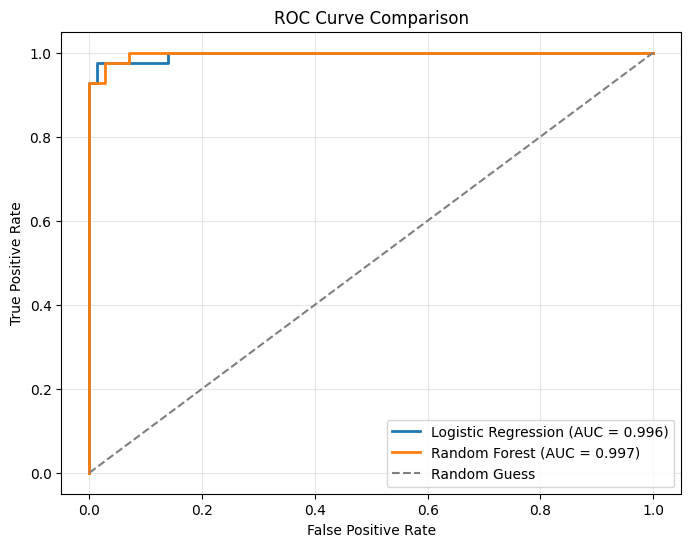

In [68]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_Rf
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label="Logistic Regression (AUC = 0.996)",
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = 0.997)",
    linewidth=2
)

# Random-guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

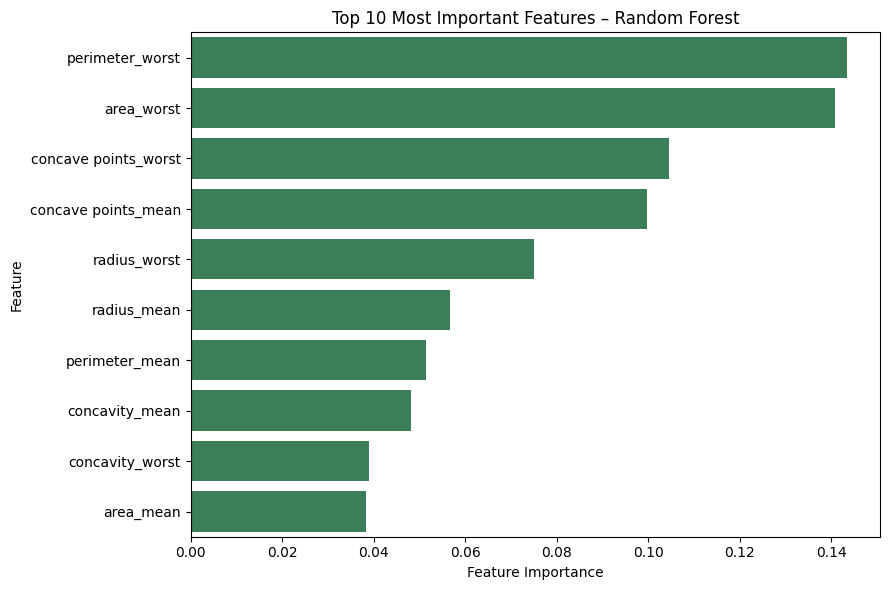

,0
perimeter_worst,0.143452
area_worst,0.140756
concave points_worst,0.104602
concave points_mean,0.099638
radius_worst,0.074990
radius_mean,0.056577
perimeter_mean,0.051409
concavity_mean,0.048216
concavity_worst,0.039051
area_mean,0.038337


In [69]:
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

top_10_features = feature_importance.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_10_features.values,
    y=top_10_features.index,
    color="seagreen"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features – Random Forest")
plt.tight_layout()
plt.show()

top_10_features

## Conclusion

This project compared Logistic Regression and Random Forest for classifying breast tumours as benign or malignant.

Both models achieved an accuracy of approximately 96.49%. Logistic Regression achieved a malignant recall of 92.86% and missed 3 malignant cases, while Random Forest achieved a malignant recall of 90.48% and missed 4 malignant cases.

Although Random Forest produced slightly higher ROC-AUC and perfect precision, Logistic Regression was selected as the preferred model because it detected more malignant cases at the default classification threshold.

The Random Forest feature-importance analysis showed that perimeter, area, radius, and concave-point measurements were among the strongest predictive features.

These results are based on a small educational dataset and a single train-test split. The models are not validated for clinical diagnosis.